<a href="https://colab.research.google.com/github/Thanchanya309/bigdata/blob/main/Project1_Part1_673020254_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project: Text Analytics for Business Insight
### SC 663 402 Data Warehouse and Big Data Analytics

##ชื่อ นางสาวธัณญ์ฌัณญา วงค์จันทร์ 673020254-0


In [ ]:
"""
หากยังไม่มี library ใด ให้ติดตั้งก่อน
!pip install -q nltk wordcloud scikit-learn pandas matplotlib tqdm huggingface_hub
!pip install -q pythainlp          # ใช้เมื่อทำงานกับข้อความภาษาไทย
"""
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
for pkg in ["punkt_tab", "stopwords", "wordnet", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

%matplotlib inline

RANDOM_SEED = 42
SAMPLE_N = 20_000         # เวอร์ชันลด workload: Part 2 ใช้อย่างน้อย 20,000 รีวิว
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)

---
# Part 1: Social Listening Warm-up
*งานเดี่ยว — ทุกคนต้องทำและส่งของตนเอง ไม่ต้องนำเสนอ (10 คะแนน)*

ใช้ข้อมูลโพสต์สาธารณะจาก **Bluesky**  
https://huggingface.co/datasets/alpindale/two-million-bluesky-posts

ใช้เพียง **1–3 ไฟล์** ก็พอ ไม่จำเป็นต้องโหลดทั้ง dataset

ฟิลด์ที่มี เช่น `text`, `created_at`, `author`, `uri`, `has_images`, `reply_to`, `predicted_language`

## ตอบ 4 คำถามหลัก

1. **คนโพสต์เมื่อไร:** จำนวนโพสต์ ช่วงเวลาที่ข้อมูลครอบคลุม และชั่วโมงที่โพสต์มากที่สุด
2. **ใช้ภาษาอะไร:** รายงานภาษาหลักและสัดส่วน เพื่อบอกว่าถ้าทำคอนเทนต์ควรรองรับภาษาใด
3. **คนพูดถึงอะไร:** หา hashtag หรือคำ/วลีเด่นที่น่าสนใจ และยกตัวอย่างข้อความจริงประกอบ
4. **ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้:** สร้าง visualization 1 รูป แล้วเขียนข้อจำกัด 3–5 บรรทัด

> Part 1 เป็น warm-up ไม่ต้องทำ influencer analysis หรือ reply-network เว้นแต่สนใจทำเพิ่มเอง


In [ ]:
# ----------------- Your code here -----------------
# ใบ้: อ่าน JSON lines ทีละบรรทัดด้วย generator ไม่ต้องโหลดทั้งไฟล์
#def iter_jsonl(path):
#     with open(path, encoding='utf-8') as f:
#         for line in f:
#             yield json.loads(line)

In [ ]:
# ----------------- Your code here -----------------

def iter_jsonl(path):
    with open(path, encoding="utf-8") as f:
        for line in f:
            yield json.loads(line)

file_path = "/content/posts_20241127_075630.jsonl"

# ลองอ่าน record แรกเพื่อตรวจโครงสร้างข้อมูล
first_post = next(iter_jsonl(file_path))

print(first_post)

{'text': '기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 쳐내주는 둠네사', 'created_at': '2024-11-27T07:56:28.535Z', 'author': 'did:plc:z3dbv7bbotsaxzdmmlwoypha', 'uri': 'at://did:plc:z3dbv7bbotsaxzdmmlwoypha/app.bsky.feed.post/3lbw3attebk2o', 'has_images': False, 'reply_to': None}


In [ ]:
# ข้อ 1: คนโพสต์เมื่อไร

total_posts = 0
timestamps = []

for post in iter_jsonl(file_path):
    total_posts += 1

    if post.get("created_at"):
        timestamps.append(post["created_at"])

times = pd.to_datetime(timestamps, format="mixed", utc=True)

print("จำนวนโพสต์ทั้งหมด:", total_posts)
print("เวลาเริ่มต้น:", times.min())
print("เวลาสิ้นสุด:", times.max())

hours = pd.Series(times.hour).value_counts().sort_index()
peak_hour = hours.idxmax()

print("ชั่วโมงที่มีการโพสต์มากที่สุด:", peak_hour)
print("จำนวนโพสต์ในชั่วโมงนั้น:", hours.max())

จำนวนโพสต์ทั้งหมด: 100000
เวลาเริ่มต้น: 2008-05-04 18:27:34+00:00
เวลาสิ้นสุด: 2024-11-30 10:50:04.343000+00:00
ชั่วโมงที่มีการโพสต์มากที่สุด: 8
จำนวนโพสต์ในชั่วโมงนั้น: 80934


### คำตอบข้อ 1: คนโพสต์เมื่อไร?

จากข้อมูลทั้งหมด 100,000 โพสต์ พบว่าข้อมูลมีช่วงเวลาตั้งแต่วันที่ 4 พฤษภาคม 2008 ถึง 30 พฤศจิกายน 2024 และชั่วโมงที่พบการโพสต์มากที่สุดคือเวลา 08:00 น. (UTC) จำนวน 80,934 โพสต์ อย่างไรก็ตาม ข้อมูลมีการกระจุกตัวอย่างผิดปกติในช่วงเวลาดังกล่าวและมีวันที่ย้อนหลังไปถึงปี 2008 จึงควรระมัดระวังในการนำผลนี้ไปตีความว่าเป็นช่วงเวลาที่ผู้ใช้นิยมโพสต์จริง

In [ ]:
# ตรวจสอบ field ที่มีอยู่ในข้อมูล
sample_posts = []

for i, post in enumerate(iter_jsonl(file_path)):
    sample_posts.append(post)
    if i == 9:
        break

for i, post in enumerate(sample_posts, 1):
    print(i, post.keys())

1 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
2 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
3 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
4 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
5 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
6 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
7 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
8 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
9 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])
10 dict_keys(['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to'])


In [ ]:
# คำตอบข้อ 2: ใช้ภาษาอะไร?
!pip install -q langdetect
from langdetect import detect, DetectorFactory
from collections import Counter

DetectorFactory.seed = RANDOM_SEED

language_counts = Counter()
detected_total = 0

for post in iter_jsonl(file_path):
    text = post.get("text", "").strip()

    if text:
        try:
            lang = detect(text)
            language_counts[lang] += 1
            detected_total += 1
        except:
            language_counts["unknown"] += 1
            detected_total += 1

print("จำนวนข้อความที่ตรวจภาษา:", detected_total)
print("\n10 ภาษาที่พบมากที่สุด:")

for lang, count in language_counts.most_common(10):
    percent = count / detected_total * 100
    print(f"{lang}: {count:,} ({percent:.2f}%)")

จำนวนข้อความที่ตรวจภาษา: 97027

10 ภาษาที่พบมากที่สุด:
en: 47,774 (49.24%)
ja: 13,101 (13.50%)
es: 4,950 (5.10%)
de: 4,319 (4.45%)
ko: 3,906 (4.03%)
fr: 3,259 (3.36%)
unknown: 2,751 (2.84%)
nl: 1,510 (1.56%)
pt: 1,396 (1.44%)
it: 1,234 (1.27%)


### คำตอบข้อ 2: ใช้ภาษาอะไร?

จากข้อความที่ไม่ว่างทั้งหมด 97,027 ข้อความ พบว่าภาษาอังกฤษมีสัดส่วนมากที่สุด 49.24% รองลงมาคือภาษาญี่ปุ่น 13.50% ภาษาสเปน 5.10% ภาษาเยอรมัน 4.45% และภาษาเกาหลี 4.03% ดังนั้น หากนำข้อมูลไปใช้วางแผนด้านเนื้อหา ควรให้ความสำคัญกับภาษาอังกฤษเป็นหลัก และรองรับภาษาญี่ปุ่นเป็นภาษาสำคัญลำดับถัดไป รวมถึงอาจพิจารณาภาษาอื่นตามกลุ่มเป้าหมาย

In [ ]:
# ข้อ 3: คนพูดถึงอะไร

hashtag_counts = Counter()
hashtag_examples = defaultdict(list)

for post in iter_jsonl(file_path):
    text = post.get("text", "")

    hashtags = re.findall(r"#\w+", text)

    for tag in hashtags:
        tag = tag.lower()
        hashtag_counts[tag] += 1

        # เก็บตัวอย่างข้อความจริง ไม่เกิน 2 ตัวอย่างต่อ hashtag
        if len(hashtag_examples[tag]) < 2:
            hashtag_examples[tag].append(text)

print("10 Hashtags ที่พบมากที่สุด:\n")

for tag, count in hashtag_counts.most_common(10):
    print(f"{tag}: {count}")

10 Hashtags ที่พบมากที่สุด:

#art: 261
#nsfw: 175
#booksky: 142
#innovation: 137
#photography: 122
#nowplaying: 108
#books: 103
#bookchallenge: 87
#bluesky: 81
#ai: 77


### คำตอบข้อ 3: คนพูดถึงอะไร?

จากการวิเคราะห์ Hashtag พบว่า #art ถูกกล่าวถึงมากที่สุด 261 ครั้ง รองลงมาคือ #nsfw 175 ครั้ง และ #booksky 142 ครั้ง นอกจากนี้ยังพบหัวข้อเกี่ยวกับ #innovation, #photography, #books และ #ai แสดงให้เห็นว่าบทสนทนาในชุดข้อมูลมีความหลากหลาย โดยมีทั้งงานศิลปะ หนังสือ การถ่ายภาพ และเทคโนโลยี จากตัวอย่างข้อความจริงพบว่า #art เกี่ยวข้องกับงานวาดและภาพประกอบ ส่วน #booksky เกี่ยวข้องกับการแบ่งปันและกิจกรรมเกี่ยวกับหนังสือ ขณะที่ #ai มีการพูดถึงเทคโนโลยีและโมเดลภาษา AI

In [ ]:
# แสดงตัวอย่างข้อความจริงจาก Hashtag ที่น่าสนใจ

selected_tags = ["#art", "#booksky", "#ai"]

for tag in selected_tags:
    print(f"\n{tag} ({hashtag_counts[tag]} posts)")
    print("-" * 50)

    for i, text in enumerate(hashtag_examples[tag], 1):
        print(f"ตัวอย่าง {i}: {text}\n")


#art (261 posts)
--------------------------------------------------
ตัวอย่าง 1: #prsk_FA #鏡音レン 
#kagaminelen #vocaloid #art

ตัวอย่าง 2: Still chipping away at this one 😇

#wip #character #artsky #art #illustration  #procreate


#booksky (142 posts)
--------------------------------------------------
ตัวอย่าง 1: Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers. day 7
#BookSky

ตัวอย่าง 2: Choose 20 books that have stayed with you or influenced you. One book per day for 20 days, in no particular order. No explanations, no reviews, just covers. 

#Books
#BookSky
#BookChallenge
#Music
#Architecture

Day 14


#ai (77 posts)
--------------------------------------------------
ตัวอย่าง 1: Great to see a European alternative to the American #AI Language models. Check out #OpenGPT-X ! 

opengpt-x.de/en/

ตัวอย่าง 2: I've just updated my webpage with some great articles. Check it out https:

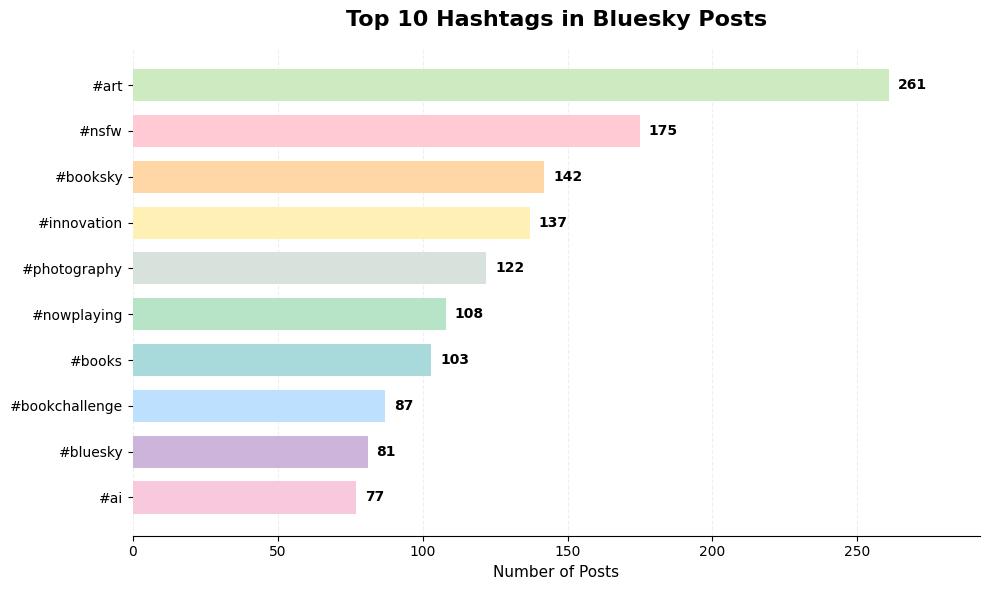

In [ ]:
# ข้อ 4: Visualization - Top 10 Hashtags

top_hashtags = hashtag_counts.most_common(10)

tags = [tag for tag, count in top_hashtags][::-1]
counts = [count for tag, count in top_hashtags][::-1]

pastel_colors = [
    "#F8C8DC",
    "#CDB4DB",
    "#BDE0FE",
    "#A8DADC",
    "#B7E4C7",
    "#D8E2DC",
    "#FFF1B6",
    "#FFD6A5",
    "#FFCAD4",
    "#CDEAC0"
]

plt.figure(figsize=(10, 6))

bars = plt.barh(
    tags,
    counts,
    color=pastel_colors,
    height=0.7
)

# ใส่จำนวนโพสต์ปลายแท่ง
for bar, count in zip(bars, counts):
    plt.text(
        bar.get_width() + 3,
        bar.get_y() + bar.get_height()/2,
        f"{count:,}",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Hashtags in Bluesky Posts",
    fontsize=16,
    fontweight="bold",
    pad=15
)

plt.xlabel("Number of Posts", fontsize=11)
plt.ylabel("")

plt.grid(axis="x", linestyle="--", alpha=0.2)
plt.gca().set_axisbelow(True)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["left"].set_visible(False)

plt.xlim(0, max(counts) * 1.12)

plt.tight_layout()
plt.show()

### คำตอบข้อ 4: ข้อมูลนี้บอกอะไรได้และบอกอะไรไม่ได้?

ข้อมูลนี้สามารถใช้สำรวจแนวโน้มเบื้องต้นเกี่ยวกับภาษาที่ผู้ใช้งานใช้และหัวข้อที่ถูกพูดถึงผ่าน Hashtag ได้ โดยกราฟ Top 10 Hashtags ช่วยให้เห็นหัวข้อที่ปรากฏบ่อยในชุดข้อมูล อย่างไรก็ตาม ข้อมูลมาจาก Bluesky เพียง 1 ไฟล์ จำนวน 100,000 โพสต์ จึงไม่สามารถใช้เป็นตัวแทนของผู้ใช้ทั้งหมดได้ นอกจากนี้ข้อมูลเวลามีค่าที่ผิดปกติ ช่น มีข้อมูลย้อนหลังไปถึงปี 2008 และมีโพสต์จำนวนมากกระจุกตัวในบางช่วงเวลา จึงควรระมัดระวังในการสรุปพฤติกรรมการโพสต์

การระบุภาษาใช้เครื่องมืออัตโนมัติ ซึ่งอาจจำแนกข้อความสั้นหรือข้อความที่มีหลายภาษาได้ไม่ถูกต้องทั้งหมด

นอกจากนี้ การวิเคราะห์หัวข้อจาก Hashtag สะท้อนเฉพาะโพสต์ที่มีการใช้ Hashtag จึงอาจไม่ครอบคลุมทุกประเด็นที่ผู้ใช้งานพูดถึง



### สรุปสั้น ๆ ถึงลูกค้า

- ข้อมูลที่วิเคราะห์ประกอบด้วยโพสต์ Bluesky จำนวน 100,000 โพสต์ โดยพบความผิดปกติบางส่วนในข้อมูลด้านเวลา จึงควรตีความพฤติกรรมการโพสต์อย่างระมัดระวัง
- จากข้อความที่ไม่ว่าง 97,027 ข้อความ พบภาษาอังกฤษมากที่สุด 49.24% รองลงมาคือภาษาญี่ปุ่น 13.50% จึงควรให้ความสำคัญกับเนื้อหาภาษาอังกฤษและญี่ปุ่น
- Hashtag ที่พบมากที่สุดคือ #art จำนวน 261 โพสต์ รองลงมาคือ #nsfw 175 โพสต์ และ #booksky 142 โพสต์
- ตัวอย่างข้อความจริงแสดงให้เห็นประเด็นที่หลากหลาย เช่น งานศิลปะ การอ่านหนังสือ และเทคโนโลยี AI
- ผลการวิเคราะห์นี้เหมาะสำหรับใช้สำรวจแนวโน้มเบื้องต้น แต่ไม่ควรนำไปสรุปแทนพฤติกรรมของผู้ใช้ Bluesky ทั้งหมด